In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)
plt.rcParams.update({'font.size': 12})
import seaborn as sns
import cmath
import math 
from matplotlib.ticker import LogLocator
from numpy.linalg import inv
from utils_SS import *
plt.rcParams['xtick.labelsize'] = 30  # Set font size for x-axis tick labels
plt.rcParams['ytick.labelsize'] = 30  # Set font size for y-axis tick labels

def custom_plot_single(fig, ax1, 
                       x_lst, y_lst, label_lst, xlim, ylim, label,pltname,
                       color=['k','r','b','g','o','c','m','y'],
                       linestyle=['solid','dashed','solid','dashed','solid','dashed'],
                       markertype=[None,None,'o','^','o','^'],
                       fillstyle=['none','none','none','none','full','full'],
                       linewidth=20*[3],
                       markevery=[450,30,50,40,56,72,63,95],
                       show_legend=True,
                       plt_outside=False, y_logscale = False):
    
    fig.patch.set_facecolor('white')
    ax1.patch.set_facecolor('white')
    #color[len(x_lst)-1] = 'gray'
    for p in range(0, len(x_lst)):
        ax1.plot(x_lst[p], y_lst[p], color[p],
                 linewidth=linewidth[p],
                 linestyle=linestyle[p],
                 marker=markertype[p],
                 fillstyle=fillstyle[p],
                 markevery=markevery[p],
                 markersize=12,
                 label=label_lst[p])

    ax1.tick_params(which='minor', width=2, length=4, color='k')
    ax1.tick_params(which='major', width=2, length=8, color='k')

    ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    if(show_legend):
        ax1.legend(prop={'size': 24},loc='best',shadow=True, frameon=False)#, bbox_to_anchor=(0.3,0.85))
    if (y_logscale):
        ax1.set_yscale('log')
        # Major ticks at powers of 10, minor ticks in between
        ax1.yaxis.set_major_locator(LogLocator(base=10.0, subs=[1.0], numticks=10))
        ax1.yaxis.set_minor_locator(LogLocator(base=10.0, subs='auto', numticks=100))

        # # Optional: show minor tick **labels**
        # ax1.tick_params(axis='y', which='minor', labelsize=20)        
    ax1.set_ylim(ylim[0],ylim[1])
    ax1.set_xlim(xlim[0],xlim[1])
    ax1.set_xlabel(label[0], fontsize=30)#, fontdict=dict(weight='bold'))
    ax1.set_ylabel(label[1], fontsize=30)#, fontdict=dict(weight='bold'))
    fontsize=30
    for tick in ax1.xaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)

    for tick in ax1.yaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    for spine in ax1.spines.values():
        spine.set_linewidth(2)  # Increase the frame thickness             
    if(plt_outside==False):
        plt.savefig(pltname, bbox_inches = "tight")
    return plt,pltname

PrintFigures=True
PointCharge=True


In [2]:
import pandas as pd
folder_path = '../figures_exp/'
Fig1d = pd.read_csv(folder_path  + 'fig1d.csv', header=None)

Vgs_exp  = Fig1d[0].to_numpy()
Ids_exp  = Fig1d[1].to_numpy() 


In [3]:
#quantum of conductance
#https://physics.nist.gov/cgi-bin/cuu/Value?conqu2e2sh
#G_quantum=2e^2/h, q=1.602e-19, h = 6.62607e-34

G_quantum  = 7.748091729e-5 #[S] 

num_CNTs = 1
Vds = 0.1
CNT_spacing = 2.556e-3
micron = 1e-6
nano=1e-9

CNTs_per_micron = micron/CNT_spacing
pts_max  = 64

m=20
n=0
acc = 0.142e-9
gamma=2.5 #eV
Temp = 298.
def get_radius(acc,m,n):
    return acc*(np.sqrt(3.)/(2*np.pi))*np.sqrt(m**2 + m*n + n**2)
    
R_cnt = get_radius(acc,m,n)
print('Radius of CNT (nm):', R_cnt/nano)

Eg_min = acc*gamma/R_cnt
print('bandgap, Eg_min/(eV):', Eg_min)

Radius of CNT (nm): 0.7828870314989447
bandgap, Eg_min/(eV): 0.45344984105855446


In [29]:
rhop_2D = []
label_str = []
Color = []
Marker=[]
Linestyle=[]
variable_occupation = []
foldername = [] 
foldername.append('../simulations/no_charge/EfmDot2')
label_str.append(r'0 trap')
Color.append('k')
Marker.append(None)
Linestyle.append('solid')
variable_occupation.append(False)

foldername.append('../simulations/dot1065nm')
label_str.append(r'$Z_p$ / (nm), SS / (mV/dec)' + '\n' +'0.1, 158')
Marker.append(None)
Linestyle.append('dashed')
variable_occupation.append(True)

foldername.append('../simulations/dot5nm')
label_str.append(r'0.5, 156')
Marker.append('o')
Linestyle.append('solid')
variable_occupation.append(True)

foldername.append('../simulations/1nm')
label_str.append(r'1.0, 134')
Marker.append('<')
Linestyle.append('solid')
variable_occupation.append(True)

foldername.append('../simulations/2nm')
label_str.append(r'2.0, 118')
Marker.append('s')
Linestyle.append('solid')
variable_occupation.append(True)

foldername.append('../simulations/3nm')
label_str.append(r'3.0, 101')
Marker.append('^')
Linestyle.append('solid')
variable_occupation.append(True)

foldername.append('../simulations/4nm')
label_str.append(r'4.0, 78')
Marker.append('x')
Linestyle.append('solid')
variable_occupation.append(True)

foldername.append('../simulations/4dot5nm')
label_str.append(r'4.5, 73')
Marker.append('>')
Linestyle.append('solid')
variable_occupation.append(True)

num_labels=np.size(label_str)
num_folders=np.size(foldername)
rhop_2D = np.array(rhop_2D)

print('num_folders', num_folders)

num_folders 8


In [30]:
num_folders=np.size(foldername)
Vgs =  np.zeros((num_folders, pts_max),dtype=float)
G   = np.zeros((num_folders, pts_max),dtype=float)
Ids_appx = np.zeros((num_folders, pts_max),dtype=float)
pts = np.zeros(num_folders,dtype=int)
#pts[:] = pts_max

In [31]:
for folder in range(num_folders):
    file_path = f"{foldername[folder]}/negf/NS_1/I.dat"
    print(str(folder) +  str(file_path))

    data = np.loadtxt(file_path, skiprows=1, usecols=(2, 7))  # Vgs = col[2], G = col[7]

    vgs_arr = np.array(data[:, 0])
    g_arr = np.array(data[:, 1])

    pts[folder] = len(vgs_arr)
    Vgs[folder][:pts[folder]] = vgs_arr
    G[folder][:pts[folder]] = g_arr
    Ids_appx[folder] =  G[folder]*G_quantum*Vds/CNT_spacing

0../simulations/no_charge/EfmDot2/negf/NS_1/I.dat
1../simulations/dot1065nm/negf/NS_1/I.dat
2../simulations/dot5nm/negf/NS_1/I.dat
3../simulations/1nm/negf/NS_1/I.dat
4../simulations/2nm/negf/NS_1/I.dat
5../simulations/3nm/negf/NS_1/I.dat
6../simulations/4nm/negf/NS_1/I.dat
7../simulations/4dot5nm/negf/NS_1/I.dat


In [32]:
def green_gradient(n, min_brightness=0.4, max_brightness=0.8):
    """
    Generate n green gradient colors from lighter to darker green,
    avoiding pure black at the darkest end.
    """
    return [
        f'#{int(50 * (1 - b)):02x}{int(255 * b):02x}{int(50 * (1 - b)):02x}'
        for b in np.linspace(max_brightness, min_brightness, n)
    ]

Color += green_gradient(num_folders-1)

In [33]:
np.shape(Color)

(8,)

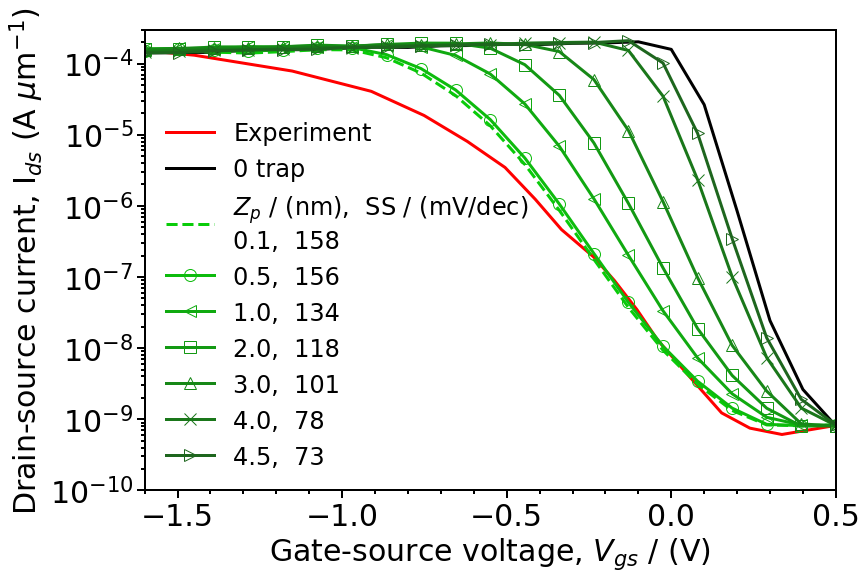

In [34]:
if(PrintFigures): 
    fig = plt.figure(figsize=(12,8))
    ax = fig.add_axes([0.18,0.15,0.8,0.8]) 
    plt,pltname = custom_plot_single(fig,ax,
                                     [Vgs_exp] + [(Vgs[f][:pts[f]]) for f in range(0, num_folders)], 
                                     [Ids_exp] + [Ids_appx[f][:pts[f]] for f in range(0, num_folders)],
                                     ['Experiment']+[', '.join(label_str[folder].split(',')) for folder in range(num_labels)],
                                     [-1.6, 0.5],
                                     [1e-10,3e-4],
                                     [r'Gate-source voltage, $V_{gs}$ / (V)',
                                      r'Drain-source current, I$_{ds}$ (A $\mu$m$^{-1}$)'],
                                     'G_zPlaneVaried.png',
                                     color=['r']+Color,
                                     linestyle=['solid']+Linestyle,
                                     markertype=[None]+Marker,
                                     markevery=[1]+[1]*num_labels,
                                     linewidth=[3]+[3]*num_labels,
                                     fillstyle=['none']+['none']*num_labels,                                     
                       show_legend=True,
                       plt_outside=True, y_logscale=True) 
    #plt.text(0.4,1.5e-5, r'$V_{ds}$ = -0.1 V', fontsize=30, color='k')
    
    plt.savefig(pltname, bbox_inches = "tight", dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')
   

In [35]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_all_charges(plt, foldername, variable_occupation, label_str, Color):
    all_Vgs_values = []
    all_total_charge_values = []
    all_fractional_active_charge_values = []
    
    for i, folder in enumerate(foldername):
        print(i,folder,variable_occupation[i])
        if variable_occupation[i]:
            filename = folder + '/point_charge/total_charge_vs_step.dat'
            print(filename)
            steps = []
            Vgs_values = []
            total_charge_values = []
            fractional_active_charge_values = []
            
            with open(filename, 'r') as file:
                lines = file.readlines()[1:]  # Skip the header
                current_step = None
                
                for line in lines:
                    cols = line.split()
                    #print(cols) #for debugging
                    step = int(cols[0])
                    Vgs = float(cols[2])
                    total_charge = float(cols[4])
                    fractional_active_charge = float(cols[5])
                    
                    # Check if the step has changed
                    if step != current_step:
                        if current_step is not None:
                            # Store the last entry before the step change
                            Vgs_values.append(last_Vgs)
                            total_charge_values.append(last_total_charge)
                            fractional_active_charge_values.append(last_fractional_active_charge)
                        current_step = step
                    
                    # Store the last values in the current step
                    last_Vgs = Vgs
                    last_total_charge = total_charge
                    last_fractional_active_charge = fractional_active_charge
                
                # Append the last set of values after the loop ends
                Vgs_values.append(last_Vgs)
                total_charge_values.append(last_total_charge)
                fractional_active_charge_values.append(last_fractional_active_charge)
            
            all_Vgs_values.append(Vgs_values)
            all_total_charge_values.append(total_charge_values)
            all_fractional_active_charge_values.append(fractional_active_charge_values)

    return np.array(all_Vgs_values), np.array(all_total_charge_values), np.array(all_fractional_active_charge_values)

In [36]:
all_Vgs_values, all_total_charge_values, all_fractional_active_charge_values = plot_all_charges(plt, foldername, variable_occupation, label_str, Color)

0 ../simulations/no_charge/EfmDot2 False
1 ../simulations/dot1065nm True
../simulations/dot1065nm/point_charge/total_charge_vs_step.dat
2 ../simulations/dot5nm True
../simulations/dot5nm/point_charge/total_charge_vs_step.dat
3 ../simulations/1nm True
../simulations/1nm/point_charge/total_charge_vs_step.dat
4 ../simulations/2nm True
../simulations/2nm/point_charge/total_charge_vs_step.dat
5 ../simulations/3nm True
../simulations/3nm/point_charge/total_charge_vs_step.dat
6 ../simulations/4nm True
../simulations/4nm/point_charge/total_charge_vs_step.dat
7 ../simulations/4dot5nm True
../simulations/4dot5nm/point_charge/total_charge_vs_step.dat


In [37]:
total_charge = all_total_charge_values
fractional_charge = all_fractional_active_charge_values
print(np.shape(total_charge))

(7, 21)


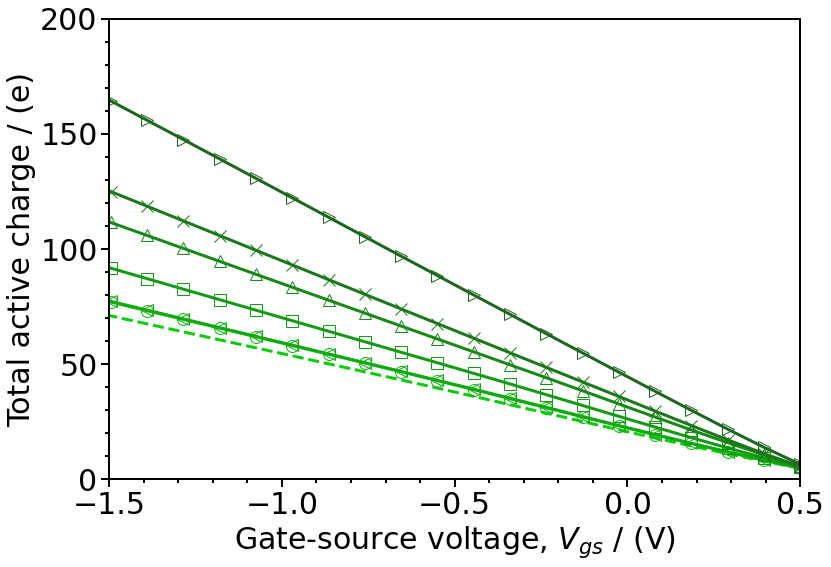

In [40]:
if PrintFigures: 
    fig = plt.figure(figsize=(12,8))
    ax = fig.add_axes([0.18,0.15,0.8,0.8])

    plt,pltname = custom_plot_single(fig, ax,
        x_lst=[(Vgs[f][:pts[f]]) for f in range(1, num_folders)],
        y_lst=[total_charge[f][:pts[f]] for f in range(np.shape(total_charge)[0])],
        label_lst=[', '.join(label_str[folder].split(',')) for folder in range(1,num_labels)],                            
        xlim=[-1.5, 0.5],
        ylim=[0, 200],
        label=['Gate-source voltage, $V_{gs}$ / (V)', 'Total active charge / (e)'],
        pltname='total_charge.png',
        color=Color[1:],
        linestyle=Linestyle[1:],
        markertype=Marker[1:],
        markevery=[1]*num_labels,
        linewidth=[3]*num_labels,
        fillstyle=['none']*num_labels,
        show_legend=False                                     
    )
    # Adding shaded regions (stddev)
    ax.set_xticks(np.arange(-1.5, 0.6, 0.5))  # X-axis ticks from -1.5 to 0.5 with a step of 0.5
    plt.savefig(pltname, bbox_inches="tight", dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')

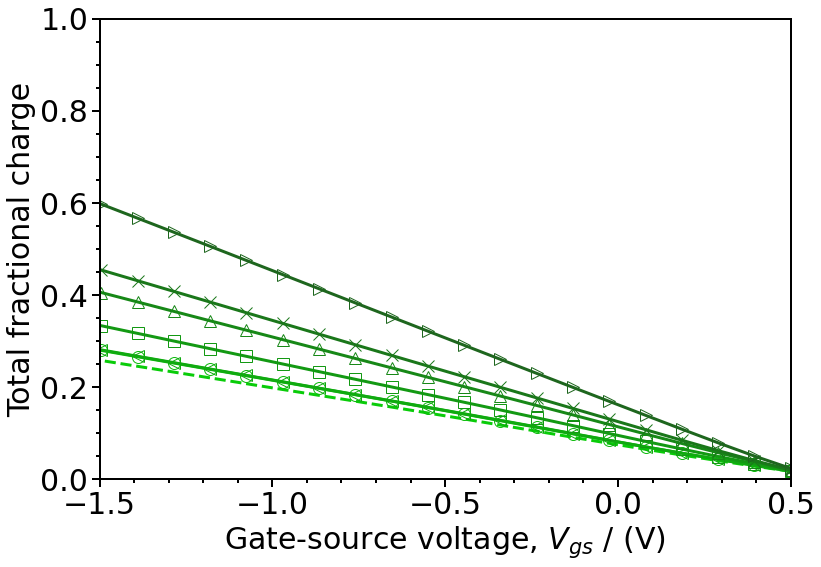

In [14]:
if PrintFigures: 
    fig = plt.figure(figsize=(12,8))
    ax = fig.add_axes([0.18,0.15,0.8,0.8])

    plt,pltname = custom_plot_single(fig, ax,
        x_lst=[(Vgs[f][:pts[f]]) for f in range(1, num_folders)],
        y_lst=[fractional_charge[f][:pts[f]] for f in range(np.shape(total_charge)[0])],
        label_lst=[', '.join(label_str[folder].split(',')) for folder in range(1,num_labels)],                            
        xlim=[-1.5, 0.5],
        ylim=[0, 1],
        label=['Gate-source voltage, $V_{gs}$ / (V)', 'Total fractional charge'],
        pltname='fractional_charge.png',
        color=Color[1:],
        linestyle=Linestyle[1:],
        markertype=Marker[1:],
        markevery=[1]*num_labels,
        linewidth=[3]*num_labels,
        fillstyle=['none']*num_labels,
        show_legend=False                                                                         
    )
    # Adding shaded regions (stddev)
    ax.set_xticks(np.arange(-1.5, 0.6, 0.5))  # X-axis ticks from -1.5 to 0.5 with a step of 0.5
    plt.savefig(pltname, bbox_inches="tight", dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')

# Compute SS and ON current (per micron)

### First read band structure and find at what voltage is the band edge in the channel kT and 4kT away from the Fermi level.

In [15]:
from scipy.interpolate import interp1d
from scipy.optimize import fsolve

num_rings=1664
E_f = -0.2 #eV
Scaling_Factor = Vds*G_quantum*CNTs_per_micron

In [16]:
print(f"num_folders: {num_folders}, pts_max: {pts_max}, num_rings: {num_rings}")
Y =  np.zeros((num_folders,pts_max,num_rings),dtype=float)
Qout  = np.zeros((num_folders,pts_max,num_rings),dtype=float)
U     = np.zeros((num_folders,pts_max,num_rings),dtype=float)
Ev  = np.zeros((num_folders,pts_max,num_rings),dtype=float)
Ec  = np.zeros((num_folders,pts_max,num_rings),dtype=float)

num_folders: 8, pts_max: 64, num_rings: 1664


In [17]:
for folder in range(num_folders):
    path = foldername[folder] + '/negf/NS_1/step'
    print(f"folder: {folder}, path: {path}")
    
    for f in range(pts[folder]):
        s=f
        fileQout = open(path+"%04d_Qout.dat"%(s))
        #print('fileQout',fileQout)
        lst = []
        counter=0
        for line in fileQout:    
            if (counter > 0 and counter < num_rings+1):
                lst += [line.split()]
            counter  = counter + 1
        y = [x[0] for x in lst]
        qout = [x[1] for x in lst]
        Y[folder][f] = np.asfarray(y)
        Qout[folder][f] = np.asfarray(qout)
        
        fileU = open(path+"%04d_U.dat"%(s))
        lst = []
        counter=0
        for line in fileU:    
            if (counter > -1 and counter < num_rings+1):
                lst += [line.split()]
            counter  = counter + 1
        u = [x[2] for x in lst]
        U[folder][f] = np.asfarray(u)
        
        # fileNorm = open(path+"%04d_norm.dat"%(s))
        # lst = []
        # counter=0
        # for line in fileNorm:    
        #     if (counter > 0 and counter < num_rings+1):
        #         lst += [line.split()]
        #     counter  = counter + 1
        # #print(counter)
        # norm = [x[1] for x in lst]
        # Norm[folder][f] = np.asfarray(norm)

Ev = -Eg_min/2. + U
Ec = Eg_min/2. + U

folder: 0, path: ../simulations/no_charge/EfmDot2/negf/NS_1/step
folder: 1, path: ../simulations/dot1065nm/negf/NS_1/step
folder: 2, path: ../simulations/dot5nm/negf/NS_1/step
folder: 3, path: ../simulations/1nm/negf/NS_1/step
folder: 4, path: ../simulations/2nm/negf/NS_1/step
folder: 5, path: ../simulations/3nm/negf/NS_1/step
folder: 6, path: ../simulations/4nm/negf/NS_1/step
folder: 7, path: ../simulations/4dot5nm/negf/NS_1/step


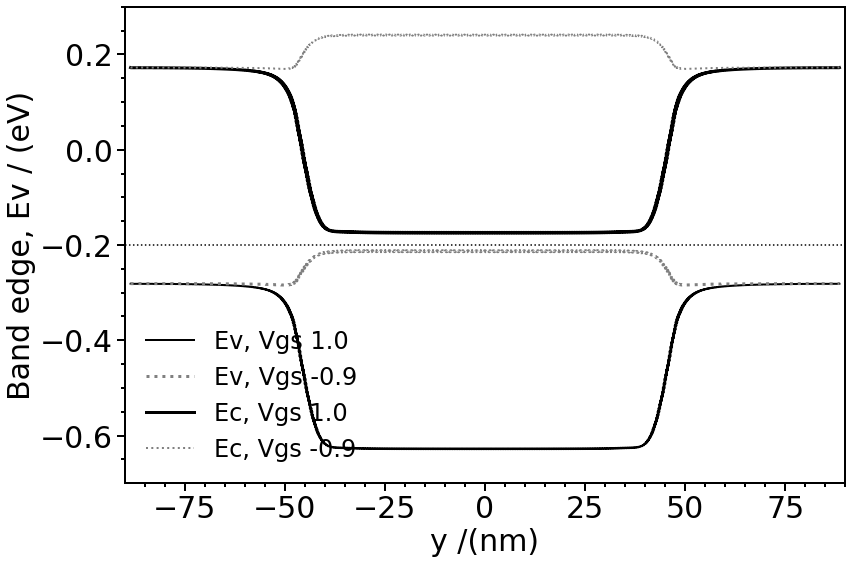

In [18]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(12,8)


if(PrintFigures):
    f=0 #folder
    i=0 #step 1 to plot bandstructure at
    j=19 # step 2 to plot bandstructure at
    delta=4 
    plt2,pltname = custom_plot_single(fig, ax,
                                     [Y[f][i], Y[f][j],Y[f][i], Y[f][j]], 
                                     [Ev[f][i], Ev[f][j],Ec[f][i], Ec[f][j]],
                                     [r'Ev, Vgs %.1f'%(Vgs[f][i]),r'Ev, Vgs %.1f'%(Vgs[f][j]),
                                      r'Ec, Vgs %.1f'%(Vgs[f][i]),r'Ec, Vgs %.1f'%(Vgs[f][j])],
                                     [-90,90],
                                     [-0.7,0.3],
                                     [r'y /(nm)',
                                      r'Band edge, Ev / (eV)'],
                                     'Ev.png',
                                     ['k','gray','k','gray','b'],
                                     linestyle=['solid','dotted','solid','dotted','solid','solid'],
                                     markertype=[None]*5,
                                     markevery=[1,1,1,1,1],
                                     linewidth=[2,3,3,2,2],
                       show_legend=True,
                       plt_outside=True, y_logscale=False)
    ax.axhline(y = E_f, color = 'k', linestyle = 'dotted')

fig.tight_layout()
#fig.savefig(filename, dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')

In [19]:
I_ON_2D =  np.zeros(num_folders,dtype=float)
SS_2D =  np.zeros(num_folders,dtype=float)

print(SS_2D.shape, rhop_2D.shape)

(8,) (0,)



folder: 1 , counter:  0
label: $Z_p$ / (nm), SS / (mV/dec)
0.1, 165
figIDi/j:  0 0
ON current / (1e-4 μA): 1.422993428857986
Vgs where barrier is  9 kT: -0.2277131350407708
Vgs where barrier is  11 kT: -0.1059948703439452
Vgs where phonon-tunneling barrier is 0.2 eV: -0.17625494442357412
	SS (mV/decade): 158.7

folder: 2 , counter:  1
label: 0.5, 163
figIDi/j:  1 0
ON current / (1e-4 μA): 1.4935871534999858
Vgs where barrier is  9 kT: -0.22091676329665041
Vgs where barrier is  11 kT: -0.10007246987951807
Vgs where phonon-tunneling barrier is 0.2 eV: -0.16996969829566586
	SS (mV/decade): 156.7

folder: 3 , counter:  2
label: 1.0, 143
figIDi/j:  2 0
ON current / (1e-4 μA): 1.6085384001570315
Vgs where barrier is  9 kT: -0.13295876498661394
Vgs where barrier is  11 kT: -0.027392012442044575
Vgs where phonon-tunneling barrier is 0.2 eV: -0.0874285462761899
	SS (mV/decade): 134.8

folder: 4 , counter:  3
label: 2.0, 128
figIDi/j:  0 1
ON current / (1e-4 μA): 1.601666364182993
Vgs where bar

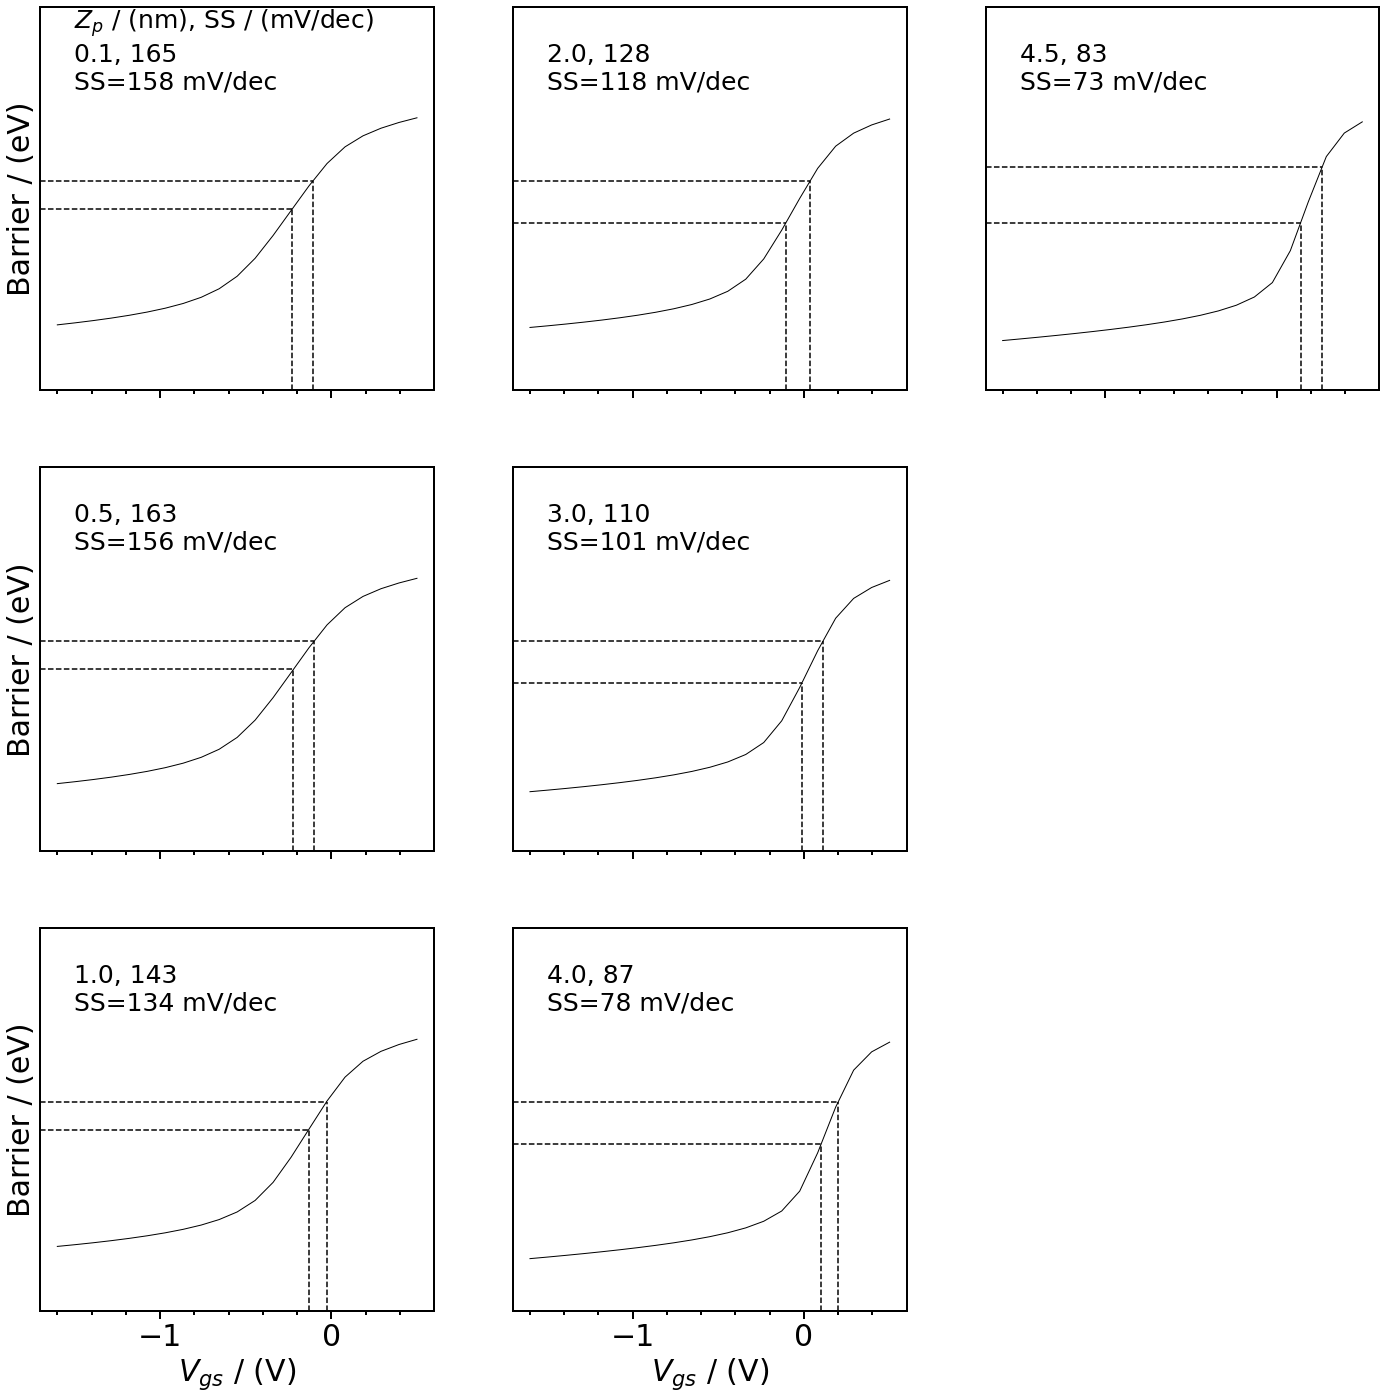

In [21]:
fig, ax = plt.subplots(3, 3, figsize=(24, 24), sharex=False, sharey=True)

# Ensure consistent Y sharing across first column
ax[2, 0].get_shared_y_axes().join(ax[0, 0], ax[1, 0], ax[2, 0])
Ef=-0.2 #eV
counter = 0  
for folder in range(1, num_folders):  # Will loop from 1 to 6
    print('\nfolder:', folder, ', counter: ', counter)
    print('label:', label_str[folder]) 
    fig_idx_i = (folder - 1) % 3
    fig_idx_j = (folder - 1) // 3
    print('figIDi/j: ', fig_idx_i, fig_idx_j)

    ax_ij = ax[fig_idx_i, fig_idx_j]

    I_ON_2D[counter] = Scaling_Factor * G[folder][pts[folder]-1]
    print('ON current / (1e-4 μA):', I_ON_2D[counter] * 1e10)

    # Choose barrier regions
    if fig_idx_j==0 and fig_idx_i < 3:
        a, b = 9, 11
    elif fig_idx_j==1 and fig_idx_i < 2:
        a, b= 8, 11
    elif fig_idx_j==1 and fig_idx_i==2:
        a, b= 8, 11
    elif fig_idx_j==2:
        a, b = 8, 12

    vgs_at_akT, vgs_at_bkT, vgs_at_phononBarrier = compute_barrier(
        U[folder][:pts[folder]],
        Vgs[folder][:pts[folder]],
        fig, ax_ij,
        Ef=Ef, a=a, b=b, Print=True
    )

    SS_2D[counter] = compute_SS(
        Vgs[folder][:pts[folder]],
        G[folder][:pts[folder]],
        vgs_at_akT, vgs_at_bkT, True
    )

    ax_ij.text(-1.5, 0.45, f"{label_str[folder]}\nSS={int(SS_2D[counter])} mV/dec",
               fontsize=25, color='k')
        
    # Remove axis labels where needed
    if fig_idx_i < 2:
        ax_ij.set_xlabel('')
        ax_ij.set_xticklabels('')
    if fig_idx_j > 0:
        ax_ij.set_ylabel('')
        ax_ij.set_yticklabels('') 

    counter += 1

# Explicitly clear axis labels and ticks for known empty subplots
for (i, j) in [(1,2),(2, 2)]:
    ax[i, j].set_xticks([])
    ax[i, j].set_yticks([])
    ax[i, j].set_xticklabels([])
    ax[i, j].set_yticklabels([])
    ax[i, j].set_xlabel('')
    ax[i, j].set_ylabel('')
    for spine in ax[i, j].spines.values():
        spine.set_visible(False)        
plt.savefig('SS_for_Zp_varied.png', bbox_inches = "tight", dpi='figure', format='png', pad_inches=0.1, facecolor='auto', edgecolor='auto')
